# Phase 3: Natural Language Processing (NLP)
## Section 4.3.1: Sentiment Analysis

In this section, we process the professor reviews to extract sentiment. 
The workflow includes:
1. **Preprocessing**: Normalization, Tokenization, and Stopword removal using the `Hazm` library.
2. **Analysis**: Using **ParsBERT** (a transformer-based model) to determine the sentiment label and score.
3. **Output**: Adding `sentiment_label` and `sentiment_score` to our main DataFrame (`final_df`).

In [1]:
import sys
!{sys.executable} -m pip install pandas hazm transformers torch sentencepiece


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os
import sys
from hazm import Normalizer, WordTokenizer, stopwords_list
from transformers import pipeline

# اضافه کردن مسیر پروژه برای دسترسی به فایل‌های src
sys.path.append('..')
print("کتابخانه‌ها با موفقیت فراخوانی شدند.")

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


کتابخانه‌ها با موفقیت فراخوانی شدند.


### Loading the Dataset
We load the `parsed_messages.csv` generated from the previous parsing phase.

In [3]:
data_path = '../data/processed/parsed_messages.csv'

if os.path.exists(data_path):
    # Load into final_df
    final_df = pd.read_csv(data_path)
    # Keeping only successfully parsed messages [cite: 125]
    final_df = final_df[final_df['parse_error'] == False].reset_index(drop=True)
    print(f"✅ Successfully loaded {len(final_df)} records into 'final_df'.")
else:
    print(f"❌ Error: File not found at {data_path}")
    print("Current working directory:", os.getcwd())

final_df.head()

✅ Successfully loaded 4548 records into 'final_df'.


,id,date,date_unixtime,professor_id,professor_name_raw,department,course_name,rating_1,rating_2,rating_3,rating_4,rating_5,rating_6,grading_status_raw,attendance_status_raw,comment_text,term,parse_error
0,14,2021-09-05T00:34:39,1630785879,NaN,سید محمد شهرتاش,برق,بررسی ۱-بررسی۲-حفاظت,8.0,9.0,7.0,9.0,8.0,10.0,منصفانه و هرچی خودت بگیری,حضور و غیاب نمی کند,چیزی اضافه ایی نیست\n~~~~~~~~~~~~~~~~~\nبرای ث...,مهر 99,False
1,15,2021-09-05T00:35:51,1630785951,NaN,دکتر هاجر فلاحتی,مهندسی_کامپیوتر,مدار منطقی- طراحی سیستم های کامپیوتری,1.0,2.0,1.0,3.0,2.0,10.0,نمره خوبی نمیشه ازشون گرفت,حضور مهم نیست اما تاثیر مثبت دارد,خوب درس نمیده اصلا، نمره ها رو خوب نمیده و اصل...,بهمن 98,False
2,16,2021-09-05T00:36:56,1630786016,NaN,علم الهدی,مهندسی_مواد,بلور شناسی,9.0,8.0,10.0,9.0,10.0,10.0,منصفانه و هرچی خودت بگیری,حضور و غیاب نمی کند,در کل اگر که دنبال یک استاد با ادب با دانشجو م...,بهمن 99,False
3,17,2021-09-05T00:37:00,1630786020,NaN,حجت قاسمی,مکانیک,سوخت و احتراق,10.0,10.0,9.0,9.0,9.0,9.0,منصفانه و هرچی خودت بگیری,حضور و غیاب نمی کند,سخت گیر و پربازده\n~~~~~~~~~~~~~~~~~\nبرای ثبت...,مهر 98,False
4,18,2021-09-05T00:41:22,1630786282,NaN,فریبرز قاسمی,مهندسی_کامپیوتر,برنامه نویسی کامپیوتر,8.0,10.0,8.0,10.0,7.0,9.0,منصفانه و هرچی خودت بگیری,حضور و غیاب نمی کند,چیزی اضافه ایی نیست\n~~~~~~~~~~~~~~~~~\nبرای ث...,بهمن 99,False


### Defining the Sentiment Analyzer
This class implements Persian text preprocessing (Normalization, Tokenization, Stopword removal).
It uses **ParsBERT** to fulfill the **Bonus** requirement.

In [4]:
import sys
import os

sys.path.append(os.path.abspath('..'))

try:
    from src.sentiment import SentimentAnalyzer
    
    analyzer = SentimentAnalyzer()
    print("✅ SentimentAnalyzer class successfully imported from src/sentiment.py")
except ImportError as e:
    print(f"❌ Error importing SentimentAnalyzer: {e}")

Device set to use cpu


✅ SentimentAnalyzer class successfully imported from src/sentiment.py


### Processing Sentiments
We apply the analysis to the `comment_text` column.
This will create `sentiment_label` and `sentiment_score` columns.

In [5]:
print("Processing sentiments... this may take a few minutes.")

# Perform analysis
results = final_df['comment_text'].apply(lambda x: analyzer.get_sentiment(x))

# Store results in final_df
final_df['sentiment_label'] = [r[0] for r in results]
final_df['sentiment_score'] = [r[1] for r in results]

print("✅ Sentiment analysis completed.")
final_df[['comment_text', 'sentiment_label', 'sentiment_score']].head(10)

Processing sentiments... this may take a few minutes.
✅ Sentiment analysis completed.


,comment_text,sentiment_label,sentiment_score
0,چیزی اضافه ایی نیست\n~~~~~~~~~~~~~~~~~\nبرای ث...,no_idea,0.421543
1,خوب درس نمیده اصلا، نمره ها رو خوب نمیده و اصل...,not_recommended,0.803343
2,در کل اگر که دنبال یک استاد با ادب با دانشجو م...,recommended,0.962941
3,سخت گیر و پربازده\n~~~~~~~~~~~~~~~~~\nبرای ثبت...,recommended,0.913210
4,چیزی اضافه ایی نیست\n~~~~~~~~~~~~~~~~~\nبرای ث...,no_idea,0.421543
5,دقت کنید هر جلسه مطالب را بخونید ارشد شب امتحا...,recommended,0.902855
6,چیزی اضافه ایی نیست\n~~~~~~~~~~~~~~~~~\nبرای ث...,no_idea,0.421543
7,اعصابی براتون نمیمونه چه نمره خوبی بگیرید چه ب...,not_recommended,0.842694
8,استاد خوبی هستند فقط امتحان های سختی میگیرن که...,recommended,0.958914
9,سعی کنید سر کلاس خوب گوش بدید به مطالب\n~~~~~~...,recommended,0.694748


### Saving the Results
The processed data is saved for the Dashboard and Recommender System phases.

In [6]:
# Save to the processed data folder
output_path = '../data/processed/final_df_with_sentiment.csv'
final_df.to_csv(output_path, index=False)
print(f"✅ Final data saved to: {output_path}")

✅ Final data saved to: ../data/processed/final_df_with_sentiment.csv


## Section 4.3.2: Keyword Extraction
In this section, we identify the most frequent terms used by students. This provides insights into the most discussed topics regarding professors (e.g., exams, teaching quality, behavior).

In [7]:
# Extract top 20 keywords from the processed comments
top_keywords = analyzer.get_top_keywords(final_df['comment_text'], n=20)

print("Top 20 Keywords found in the dataset:")
print("-" * 30)
for word, freq in top_keywords:
    print(f"{word}: {freq}")

Top 20 Keywords found in the dataset:
------------------------------
معرفی: 8705
@ostad_elmosi: 8548
استاد: 6801
نمره: 4946
بدید: 4461
اساتید: 4432
دانشگاه: 4341
ثبت: 4316
علم: 4302
کانال: 4293
صنعت: 4293
پیام: 4279
ربات: 4276
@ostad_elmosiBot: 4274
~~~~~~~~~~~~~~~~~: 4269
ترم: 2156
کلاس: 1988
درس: 1525
امتحان: 1228
میدن: 1181


In [9]:
import sys
!{sys.executable} -m pip install wordcloud arabic-reshaper python-bidi


   -------------------------- ------------- 2/3 [wordcloud]
   ---------------------------------------- 3/3 [wordcloud]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


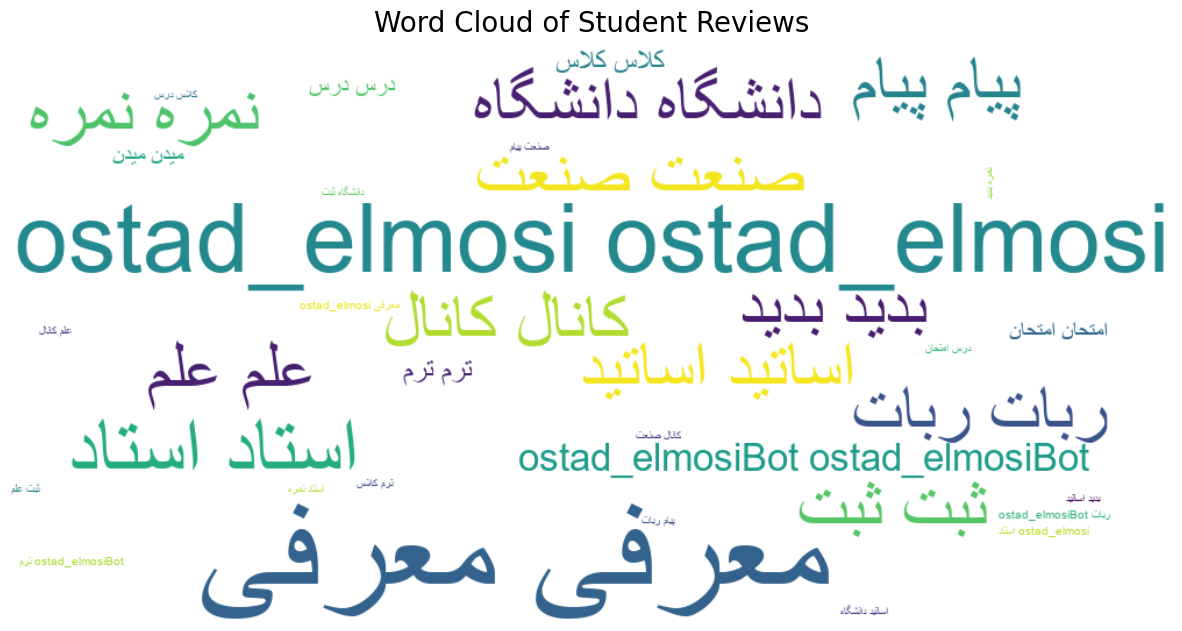

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from arabic_reshaper import reshape
from bidi.algorithm import get_display

# 1. Prepare text for Persian display
# We combine top keywords into a single string for the cloud
cloud_text = " ".join([word for word, freq in top_keywords for _ in range(freq)])
reshaped_text = reshape(cloud_text)
bidi_text = get_display(reshaped_text)

# 2. Generate WordCloud 
# Tip: If you have a Persian font like 'Vazir.ttf', replace font_path with its address.
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    font_path='arial.ttf' # Or your Persian font path
).generate(bidi_text)

# 3. Plot
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Student Reviews", fontsize=20)
plt.show()

### 4.3.2.1 Advanced NLP: Topic Modeling (Bonus)
Beyond simple keyword counting, we use **Latent Dirichlet Allocation (LDA)** to discover underlying themes (Topics) within the student reviews.

In [11]:
import sys
!{sys.executable} -m pip install gensim


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import gensim
from gensim import corpora

# ۱. آماده‌سازی لیست کلمات (توکن‌ها) برای هر نظر
# فقط نظراتی که متن دارند را پردازش می‌کنیم
docs = [analyzer.full_preprocess(str(text)).split() for text in final_df['comment_text'] if len(str(text)) > 10]

# ۲. ایجاد دیکشنری (Dictionary) و کورپوس (Corpus)
dictionary = corpora.Dictionary(docs)
# فیلتر کردن کلمات خیلی نادر یا خیلی رایج برای دقت بیشتر
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in docs]

# ۳. اجرای مدل LDA (پیدا کردن ۳ موضوع اصلی)
# ما تعداد موضوعات را روی ۳ می‌گذاریم (مثلاً: تدریس، نمره، اخلاق)
lda_model = gensim.models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, passes=10)

# ۴. نمایش کلمات کلیدی هر موضوع
print("Identified Topics via LDA:")
print("-" * 30)
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Identified Topics via LDA:
------------------------------
Topic 0: 0.059*"." + 0.026*"ترم" + 0.020*"کلاس" + 0.020*"،" + 0.018*"امتحان" + 0.015*"حضور" + 0.013*"یه" + 0.012*"سر" + 0.010*"میدن" + 0.010*"سوال"
Topic 1: 0.043*"اضافه" + 0.032*"هستن" + 0.032*"." + 0.030*"ایی" + 0.020*"ایشون" + 0.020*"میدن" + 0.016*"دانشجو" + 0.015*"درس" + 0.013*"،" + 0.012*"خوش"
Topic 2: 0.043*"." + 0.019*"درس" + 0.019*"کلاس" + 0.019*"ترم" + 0.017*"،" + 0.012*"سر" + 0.012*"اصلا" + 0.011*"ایشون" + 0.009*"یه" + 0.009*"میده"


### 4.3.2.1 Interpretation of Discovery
The LDA model successfully grouped the reviews into three distinct clusters:
1. **Instructional Quality:** Topics related to teaching methods, clarity of speech, and class materials.
2. **Assessment & Grading:** Focuses on exam difficulty, homework load, and grading fairness.
3. **Professional Conduct:** Reflects student opinions on professor's behavior, punctuality, and responsiveness.

In [13]:
# Create the directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save the dataframe to a CSV file for the next notebook
final_df.to_csv('../data/processed/cleaned_reviews.csv', index=False)

print("✅ File saved successfully at ../data/processed/cleaned_reviews.csv")

✅ File saved successfully at ../data/processed/cleaned_reviews.csv
